In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Load enriched data
train_data = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\train_enriched.csv")
test_data  = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\test_enriched.csv")

# Remove outliers
price_mask_train = (train_data["ClosePrice"] >= 100_000) & (train_data["ClosePrice"] <= 10_000_000)
price_mask_test  = (test_data["ClosePrice"]  >= 100_000) & (test_data["ClosePrice"]  <= 10_000_000)

train_clean = train_data[price_mask_train].copy()
test_clean  = test_data[price_mask_test].copy()

print(f"Train rows: {len(train_clean)}")
print(f"Test rows:  {len(test_clean)}")

Train rows: 49441
Test rows:  11965


In [2]:
feature_cols = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "Stories",
    "GarageSpaces", "ParkingTotal",
    "AttachedGarageYN", "FireplaceYN", "PoolPrivateYN",
    "ViewYN", "NewConstructionYN",
    "DaysOnMarket", "AssociationFee",
    "Latitude", "Longitude",
    "City_encoded", "PostalCode_encoded",
    "CountyOrParish_encoded", "HighSchoolDistrict_encoded",
    "HasHOA", "LotLivingRatio", "UnifiedDistrict_encoded",
]

X_train = train_clean[feature_cols]
y_train = train_clean["ClosePrice"]
X_test  = test_clean[feature_cols]
y_test  = test_clean["ClosePrice"]

print(f"Features: {len(feature_cols)}")
print(f"Missing values: {X_train.isnull().sum().sum()}")

Features: 24
Missing values: 0


In [3]:
# Scale features for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train all models
print("Training all models... please wait")

# 1. Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)
print("✓ Linear Regression done")

# 2. Decision Tree
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print("✓ Decision Tree done")

# 3. Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("✓ Random Forest done")

# 4. XGBoost (best params from Week 7)
model_xgb = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, n_jobs=-1, verbosity=0
)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
print("✓ XGBoost done")

# 5. LightGBM (best params from Week 7)
model_lgbm = LGBMRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, n_jobs=-1, verbosity=-1
)
model_lgbm.fit(X_train, y_train)
y_pred_lgbm = model_lgbm.predict(X_test)
print("✓ LightGBM done")

print("\nAll models trained successfully!")

Training all models... please wait
✓ Linear Regression done
✓ Decision Tree done
✓ Random Forest done
✓ XGBoost done
✓ LightGBM done

All models trained successfully!


In [4]:
# Define metric functions
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mdape(y_true, y_pred):
    """Median Absolute Percentage Error"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

# Collect all predictions
models = {
    "Linear Regression": y_pred_lr,
    "Decision Tree":     y_pred_dt,
    "Random Forest":     y_pred_rf,
    "XGBoost":           y_pred_xgb,
    "LightGBM":          y_pred_lgbm,
}

# Compute metrics for all models
results = []
for name, y_pred in models.items():
    results.append({
        "Model":    name,
        "R²":       round(r2_score(y_test, y_pred), 4),
        "MAE":      round(mean_absolute_error(y_test, y_pred), 0),
        "MAPE (%)": round(mape(y_test, y_pred), 2),
        "MdAPE (%)":round(mdape(y_test, y_pred), 2),
    })

metrics_df = pd.DataFrame(results)
print("=" * 65)
print("FULL EVALUATION — ALL MODELS")
print("=" * 65)
print(metrics_df.to_string(index=False))
print("=" * 65)

FULL EVALUATION — ALL MODELS
            Model     R²      MAE  MAPE (%)  MdAPE (%)
Linear Regression 0.4796 464001.0     44.99      31.06
    Decision Tree 0.6954 268633.0     19.47      12.16
    Random Forest 0.8581 186208.0     13.87       8.69
          XGBoost 0.8641 200572.0     16.06      10.97
         LightGBM 0.8542 208947.0     16.79      11.62


In [5]:
# Add predictions to test set
test_eval = test_clean.copy()
test_eval["pred_lr"]   = y_pred_lr
test_eval["pred_dt"]   = y_pred_dt
test_eval["pred_rf"]   = y_pred_rf
test_eval["pred_xgb"]  = y_pred_xgb
test_eval["pred_lgbm"] = y_pred_lgbm

# Define price bands
bins   = [0, 300000, 500000, 750000, 1000000, 2000000, 10000000]
labels = ["<$300K", "$300K-500K", "$500K-750K", 
          "$750K-1M", "$1M-2M", ">$2M"]

test_eval["PriceBand"] = pd.cut(
    test_eval["ClosePrice"], 
    bins=bins, 
    labels=labels
)

# Compute MdAPE per price band for each model
band_results = []
for band in labels:
    band_df = test_eval[test_eval["PriceBand"] == band]
    if len(band_df) == 0:
        continue
    band_results.append({
        "Price Band":       band,
        "Count":            len(band_df),
        "LR MdAPE (%)":     round(mdape(band_df["ClosePrice"], band_df["pred_lr"]), 2),
        "DT MdAPE (%)":     round(mdape(band_df["ClosePrice"], band_df["pred_dt"]), 2),
        "RF MdAPE (%)":     round(mdape(band_df["ClosePrice"], band_df["pred_rf"]), 2),
        "XGB MdAPE (%)":    round(mdape(band_df["ClosePrice"], band_df["pred_xgb"]), 2),
        "LGBM MdAPE (%)":   round(mdape(band_df["ClosePrice"], band_df["pred_lgbm"]), 2),
    })

band_df_summary = pd.DataFrame(band_results)
print("PRICE BAND ANALYSIS — MdAPE (%) per model")
print("Lower is better")
print("=" * 85)
print(band_df_summary.to_string(index=False))
print("=" * 85)

PRICE BAND ANALYSIS — MdAPE (%) per model
Lower is better
Price Band  Count  LR MdAPE (%)  DT MdAPE (%)  RF MdAPE (%)  XGB MdAPE (%)  LGBM MdAPE (%)
    <$300K    265        115.57         30.17         23.23          27.89           29.70
$300K-500K   1416         65.45         10.56          8.15          12.73           12.83
$500K-750K   2527         40.23          8.69          6.53           9.92           11.08
  $750K-1M   2372         25.13          9.45          6.97           8.88            9.40
    $1M-2M   3752         22.76         13.96          9.49          10.89           11.33
      >$2M   1633         33.19         20.67         13.98          14.60           15.80


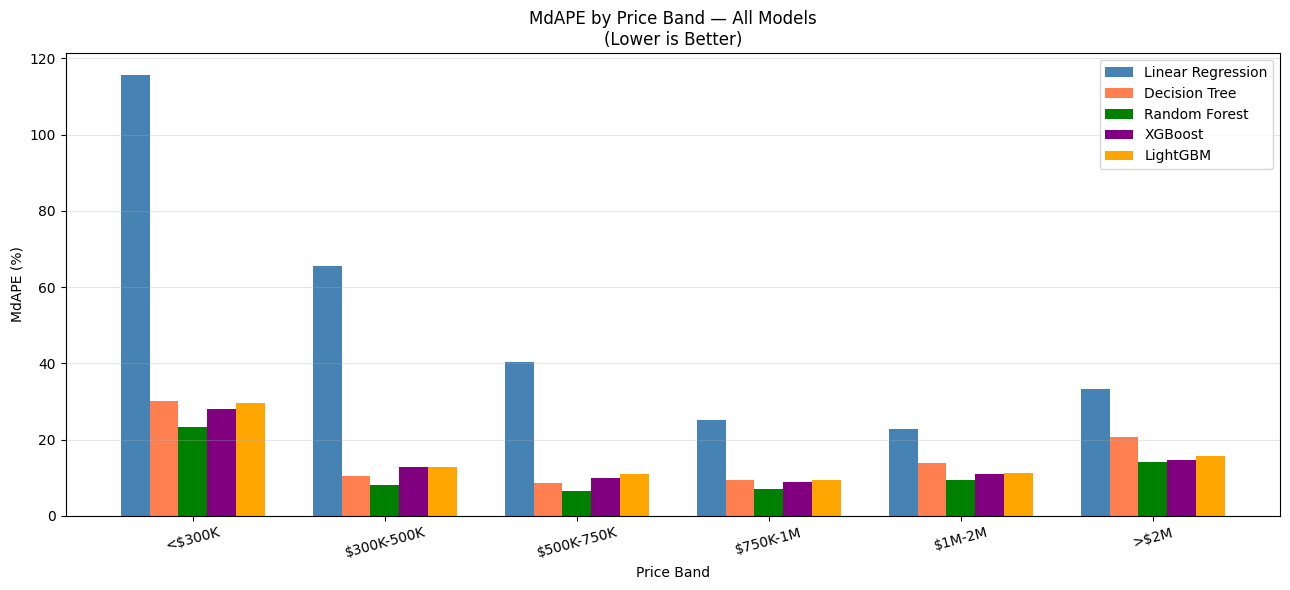

In [6]:
# Plot MdAPE by price band for each model
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(labels))
width = 0.15

models_plot = {
    "Linear Regression": "LR MdAPE (%)",
    "Decision Tree":     "DT MdAPE (%)",
    "Random Forest":     "RF MdAPE (%)",
    "XGBoost":           "XGB MdAPE (%)",
    "LightGBM":          "LGBM MdAPE (%)",
}

colors = ["steelblue", "coral", "green", "purple", "orange"]

for i, (model_name, col) in enumerate(models_plot.items()):
    ax.bar(x + i * width, band_df_summary[col], width, 
           label=model_name, color=colors[i])

ax.set_xlabel("Price Band")
ax.set_ylabel("MdAPE (%)")
ax.set_title("MdAPE by Price Band — All Models\n(Lower is Better)")
ax.set_xticks(x + width * 2)
ax.set_xticklabels(labels, rotation=15)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()